In [1]:
import os
import re
import math
import sys
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from openai import OpenAI
from anthropic import Anthropic

In [2]:
load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [3]:
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
from src import items
from src.tester import Tester

sys.modules['items'] = items
from src.items import Item

In [5]:
openai = OpenAI()

In [6]:
%matplotlib inline

In [7]:
with open('data/train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('data/test.pkl', 'rb') as file:
    test = pickle.load(file)

In [8]:
fine_tune_train = train[:200]
fine_tune_validation = train[200:250]

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI

In [9]:
def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [10]:
messages_for(train[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': "How much does this cost?\n\n2 Pack JBL Clip 4 Waterproof Wireless Audio Bluetooth Speaker Bundle (Black)\nIT'S ALL ABOUT THE SOUND! Music here, there, everywhere. Clip and play, cool, portable, and waterproof! The vibrant fresh looking JBL Clip 4 delivers surprisingly rich JBL Original Pro Sound in a compact package. The unique oval shape fits easy in your hand. Fully wrapped in colorful fabrics with expressive details inspired by current street fashion, it’s easy to match your style. The fully integrated carabiner hooks instantly to bags, belts, or buckles, to bring your favorite tunes anywhere. Waterproof, dustproof, and up to 10 hours of playtime, it’s rugged enough to tag along wherever you explore. This Exclusive Bundle includes two JBL Clip 4 speakers .Cool,"},
 {'role': 'assistant', 'content': 'Price is $97.66'}]

In [11]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:

def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [12]:
print(make_jsonl(train[:1]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\n2 Pack JBL Clip 4 Waterproof Wireless Audio Bluetooth Speaker Bundle (Black)\nIT'S ALL ABOUT THE SOUND! Music here, there, everywhere. Clip and play, cool, portable, and waterproof! The vibrant fresh looking JBL Clip 4 delivers surprisingly rich JBL Original Pro Sound in a compact package. The unique oval shape fits easy in your hand. Fully wrapped in colorful fabrics with expressive details inspired by current street fashion, it\u2019s easy to match your style. The fully integrated carabiner hooks instantly to bags, belts, or buckles, to bring your favorite tunes anywhere. Waterproof, dustproof, and up to 10 hours of playtime, it\u2019s rugged enough to tag along wherever you explore. This Exclusive Bundle includes two JBL Clip 4 speakers .Cool,"}, {"role": "assistant", "content": "Price is $97.66"}]}


In [13]:
def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [14]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [15]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

In [16]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [17]:
train_file

FileObject(id='file-DEkGN9ne32rS6pW6f4BYAs', bytes=183665, created_at=1761134698, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [18]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

https://wandb.ai

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

In [19]:
wandb_integration = {"type": "wandb", "wandb": {"project": "gpt-pricer"}}

In [20]:
train_file.id

'file-DEkGN9ne32rS6pW6f4BYAs'

In [21]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": 1},
    integrations = [wandb_integration],
    suffix="pricer"
)

FineTuningJob(id='ftjob-tjSJFcwBRaujHWUUPma9koTf', created_at=1761134703, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-aS7ceXEMMlvewwDCSC407y9a', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-DEkGN9ne32rS6pW6f4BYAs', validation_file='file-C26WRvr8khhnRpmJP4oVzd', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-tjSJFcwBRaujHWUUPma9koTf'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='price

In [22]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-tjSJFcwBRaujHWUUPma9koTf', created_at=1761134703, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-aS7ceXEMMlvewwDCSC407y9a', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-DEkGN9ne32rS6pW6f4BYAs', validation_file='file-C26WRvr8khhnRpmJP4oVzd', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-tjSJFcwBRaujHWUUPma9koTf'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epoc

In [23]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [24]:
job_id

'ftjob-tjSJFcwBRaujHWUUPma9koTf'

In [27]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-tjSJFcwBRaujHWUUPma9koTf', created_at=1761134703, error=Error(code=None, message=None, param=None), fine_tuned_model='ft:gpt-4o-mini-2024-07-18:personal:pricer:CTS2GFnb', finished_at=1761135314, hyperparameters=Hyperparameters(batch_size=1, learning_rate_multiplier=1.8, n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-aS7ceXEMMlvewwDCSC407y9a', result_files=['file-PhygaZgFovKFye4Nb4y49u'], seed=42, status='succeeded', trained_tokens=37876, training_file='file-DEkGN9ne32rS6pW6f4BYAs', validation_file='file-C26WRvr8khhnRpmJP4oVzd', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-tjSJFcwBRaujHWUUPma9koTf'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size=1, learning_ra

In [28]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-ifCAeyp6Uq8cIdIII6xFQ7BF', created_at=1761136119, level='info', message='The job has successfully completed', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-b1XxwK1anMCLSGWM4wTu36ZV', created_at=1761136112, level='info', message='Usage policy evaluations completed, model is now enabled for sampling', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-0sQNjttxe9cw2EuKWqR0ic44', created_at=1761136112, level='info', message='Moderation checks for snapshot ft:gpt-4o-mini-2024-07-18:personal:pricer:CTS2GFnb passed.', object='fine_tuning.job.event', data={'blocked': False, 'results': [{'flagged': False, 'category': 'harassment/threatening', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'sexual', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'sexual/minors', 'enforcement': 'blocking'}, {'flagged': False, 'category': 'propaganda', 'enforcement': 'blocking'

In [29]:
import wandb
from wandb.integration.openai.fine_tuning import WandbLogger

wandb.login()
WandbLogger.sync(fine_tune_job_id=job_id, project="gpt-pricer")

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: Retrieving fine-tune job...
wandb: Currently logged in as: onurtosun to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [anthropic, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/
wandb: Waiting for the OpenAI fine-tuning job to finish training...
wandb: To avoid blocking, you can call `WandbLogger.sync` with `wait_for_job_success=False` after OpenAI training completes.
wandb: Fine-tuning finished, logging metrics, model metadata, and run metadata to Weights & Biases
wandb: Logging training/validation files...


train_accuracy,▃▁▃▅▆▆▆▆▆▆▆▆██▆█▆▆▆▆█▆▆▆▆▆██▆▆█▆▆▆▆██▆▆▆
train_loss,▇█▆▃▃▂▂▂▂▂▂▂▂▂▂▃▂▂▁▁▂▂▂▁▁▂▂▂▂▂▂▁▂▂▂▁▂▂▂▁
valid_loss,▄▅▅▄▄▅▆▂▁▂▆▃▃█▃▄▃▂▄▅
valid_mean_token_accuracy,▁▁█▁▁█▁███▁█▁▁██▁███
fine_tuned_model,ft:gpt-4o-mini-2024-...
status,succeeded
train_accuracy,0.75
train_loss,1.52613
valid_loss,1.01732
valid_mean_token_accuracy,0.875


'🎉 wandb sync completed successfully'

In [31]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [32]:
fine_tuned_model_name

'ft:gpt-4o-mini-2024-07-18:personal:pricer:CTS2GFnb'

In [33]:

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [ ]:
messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': "How much does this cost?\n\nDisney Animators' Littles Rapunzel Surprise Feature Playset - Tangled\nTowering new heights of fairytale fun are to be had with this Surprise Feature Playset, inspired by Tangled. Part of the Disney Animators' Collection, the adorable playset features Rapunzel, Pascal, a mystery figure, and more! Genuine, Original, Authentic Disney Store Pop-up playset includes nine pieces Pieces include Rapunzel, Pascal, painting, guitar, mirror, chair, and wardrobe Two figures act as keys to unlock music, lights, and sounds Rapunzel's tower features a highly detailed exterior, light-up window, and top carry handle Dimensions 9 x 7 x 4 inches, Weight 1.04 pounds, Manufacturer recommended age 3 years and"},
 {'role': 'assistant', 'content': 'Price is $'}]

In [35]:
def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [36]:
def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name,
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [37]:
print(test[0].price)
print(gpt_fine_tuned(test[0]))

48.95
49.99


1: Guess: $49.99 Truth: $48.95 Error: $1.04 SLE: 0.00 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $5.99 Truth: $9.99 Error: $4.00 SLE: 0.20 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $274.00 Truth: $167.98 Error: $106.02 SLE: 0.24 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $54.99 Truth: $166.08 Error: $111.09 SLE: 1.20 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $31.99 Truth: $44.30 Error: $12.31 SLE: 0.10 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $66.47 Truth: $299.99 Error: $233.52 SLE: 2.24 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $10.99 Truth: $6.39 Error: $4.60 SLE: 0.23 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $649.00 Truth: $639.95 Error: $9.05 SLE: 0.00 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $972.66 Truth: $530.00 Error: $442.66 SLE: 0.37 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $43.66 Truth: $59.95 Error: $16.29 SLE: 0.10 It

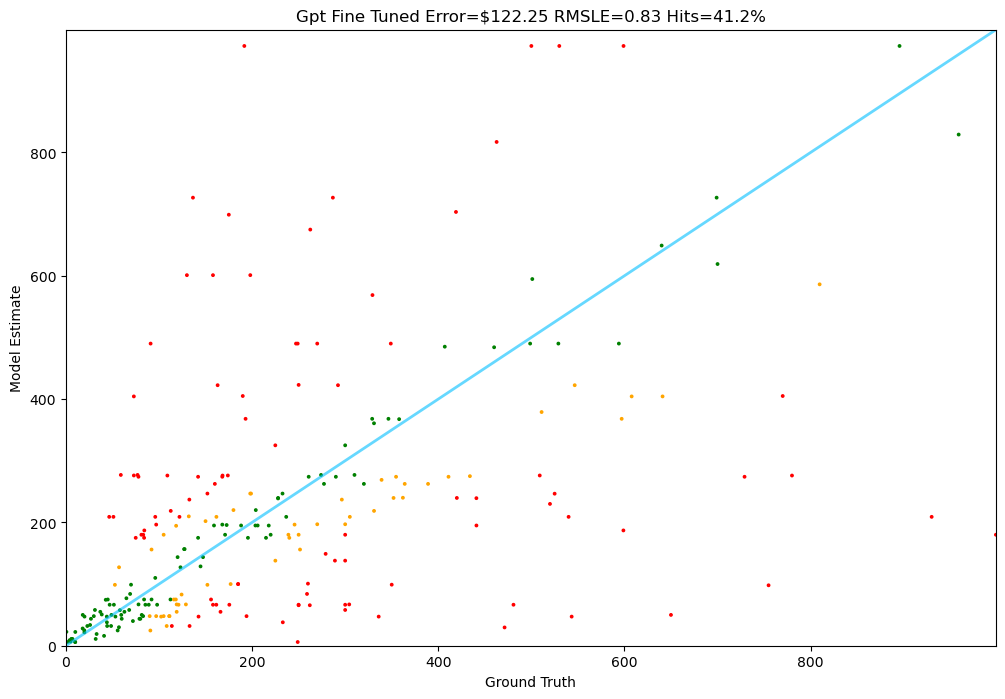

In [38]:
Tester.test(gpt_fine_tuned, test)

In [39]:
## Improve the fine-tuned model further via prompting

def improvement_messages_for(item):
    system_message = """You are an Amazon marketplace pricing expert. Analyze product descriptions to predict accurate Amazon selling prices based on typical marketplace dynamics and consumer behavior patterns.

Key Amazon pricing factors to evaluate:
- Brand strength (Apple, Samsung, Nike = premium; generic/unbranded = budget)
- Product category positioning (Home & Kitchen, Electronics, Sports, Beauty, etc.)
- Pack size and quantity (bulk/multi-packs often better per-unit value)
- Prime eligibility indicators and fulfillment method signals
- Product variations (color, size, model) affecting price tiers
- Feature density and specification richness
- Amazon's Choice or bestseller indicators in description
- Customer rating implications (4.5+ stars = premium pricing power)
- Seasonal/trending product indicators

Amazon-specific pricing patterns:
- Electronics: $10-50 (accessories), $50-200 (mid-tier), $200+ (premium)
- Home/Kitchen: $15-40 (small items), $40-150 (appliances), $150+ (major items)
- Beauty/Personal Care: $8-25 (drugstore), $25-60 (prestige), $60+ (luxury)
- Sports/Outdoors: $20-80 (equipment), $30-120 (apparel), $100+ (specialized gear)
- Books/Media: $10-20 (paperback), $15-35 (hardcover), $25-50 (specialty)
- Toys/Games: $15-40 (standard), $40-100 (premium/electronic)

Consider Amazon's psychological pricing (ends in .99, .95, .49) and competitive marketplace pressure.

Output format: Respond with only the price including dollar sign and cents (e.g., "$24.99"). No explanations or additional text."""
    
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"${item.price:.2f}"}
    ]

In [43]:
def make_improvement_jsonl(items):
    result = ""
    for item in items:
        messages = improvement_messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [44]:
print(make_improvement_jsonl(train[:3]))

{"messages": [{"role": "system", "content": "You are an Amazon marketplace pricing expert. Analyze product descriptions to predict accurate Amazon selling prices based on typical marketplace dynamics and consumer behavior patterns.\n\nKey Amazon pricing factors to evaluate:\n- Brand strength (Apple, Samsung, Nike = premium; generic/unbranded = budget)\n- Product category positioning (Home & Kitchen, Electronics, Sports, Beauty, etc.)\n- Pack size and quantity (bulk/multi-packs often better per-unit value)\n- Prime eligibility indicators and fulfillment method signals\n- Product variations (color, size, model) affecting price tiers\n- Feature density and specification richness\n- Amazon's Choice or bestseller indicators in description\n- Customer rating implications (4.5+ stars = premium pricing power)\n- Seasonal/trending product indicators\n\nAmazon-specific pricing patterns:\n- Electronics: $10-50 (accessories), $50-200 (mid-tier), $200+ (premium)\n- Home/Kitchen: $15-40 (small items

In [45]:
def write_improvement_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_improvement_jsonl(items)
        f.write(jsonl)

In [61]:
write_improvement_jsonl(fine_tune_train, "fine_tune_train_improvement.jsonl")

In [66]:
write_improvement_jsonl(fine_tune_validation, "fine_tune_validation_improvement.jsonl")

In [67]:
with open("fine_tune_train_improvement.jsonl", "rb") as f:
    train_file_improvement = openai.files.create(file=f, purpose="fine-tune")

In [68]:
with open("fine_tune_validation_improvement.jsonl", "rb") as f:
    validation_file_improvement = openai.files.create(file=f, purpose="fine-tune")

In [69]:
train_file_improvement.id

'file-5yrREsitsCXXEXUKWy9ANc'

In [70]:
openai.fine_tuning.jobs.create(
    training_file=train_file_improvement.id,
    validation_file=validation_file_improvement.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": 1},
    integrations = [wandb_integration],
    suffix="pricer"
)

FineTuningJob(id='ftjob-Qiozqtpi1XucLIe5fUfRaOYL', created_at=1761137309, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-aS7ceXEMMlvewwDCSC407y9a', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-5yrREsitsCXXEXUKWy9ANc', validation_file='file-2R3k8GeeyG3x8iDKMfiB9K', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-Qiozqtpi1XucLIe5fUfRaOYL'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='price

In [71]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-Qiozqtpi1XucLIe5fUfRaOYL', created_at=1761137309, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-aS7ceXEMMlvewwDCSC407y9a', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-5yrREsitsCXXEXUKWy9ANc', validation_file='file-2R3k8GeeyG3x8iDKMfiB9K', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-Qiozqtpi1XucLIe5fUfRaOYL'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epoc

In [72]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [73]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-Qiozqtpi1XucLIe5fUfRaOYL', created_at=1761137309, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-aS7ceXEMMlvewwDCSC407y9a', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-5yrREsitsCXXEXUKWy9ANc', validation_file='file-2R3k8GeeyG3x8iDKMfiB9K', estimated_finish=None, integrations=[FineTuningJobWandbIntegrationObject(type='wandb', wandb=FineTuningJobWandbIntegration(project='gpt-pricer', entity=None, name=None, tags=None, run_id='ftjob-Qiozqtpi1XucLIe5fUfRaOYL'))], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='price

In [79]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-E4gcwMwoUqUIGHVoWdqyk6jb', created_at=1761137810, level='info', message='Step 164/200: training loss=1.48', object='fine_tuning.job.event', data={'step': 164, 'train_loss': 1.4789152145385742, 'total_steps': 200, 'train_mean_token_accuracy': 0.6666666666666666}, type='metrics'),
 FineTuningJobEvent(id='ftevent-8FEzvuY13ke1RMLIPwm90P2B', created_at=1761137807, level='info', message='Step 163/200: training loss=1.83', object='fine_tuning.job.event', data={'step': 163, 'train_loss': 1.8296772241592407, 'total_steps': 200, 'train_mean_token_accuracy': 0.6666666666666666}, type='metrics'),
 FineTuningJobEvent(id='ftevent-VQcXcO1sNtkZae7umOzwJ5qn', created_at=1761137807, level='info', message='Step 162/200: training loss=1.53', object='fine_tuning.job.event', data={'step': 162, 'train_loss': 1.527732491493225, 'total_steps': 200, 'train_mean_token_accuracy': 0.6666666666666666}, type='metrics'),
 FineTuningJobEvent(id='ftevent-pjW6WGUikaqyYxCG0ZyXyiTj', create

In [88]:
fine_tuned_model_name_improvement = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [89]:
def messages_for(item):
    system_message = """You are an Amazon marketplace pricing expert. Analyze product descriptions to predict accurate Amazon selling prices based on typical marketplace dynamics and consumer behavior patterns.

Key Amazon pricing factors to evaluate:
- Brand strength (Apple, Samsung, Nike = premium; generic/unbranded = budget)
- Product category positioning (Home & Kitchen, Electronics, Sports, Beauty, etc.)
- Pack size and quantity (bulk/multi-packs often better per-unit value)
- Prime eligibility indicators and fulfillment method signals
- Product variations (color, size, model) affecting price tiers
- Feature density and specification richness
- Amazon's Choice or bestseller indicators in description
- Customer rating implications (4.5+ stars = premium pricing power)
- Seasonal/trending product indicators

Amazon-specific pricing patterns:
- Electronics: $10-50 (accessories), $50-200 (mid-tier), $200+ (premium)
- Home/Kitchen: $15-40 (small items), $40-150 (appliances), $150+ (major items)
- Beauty/Personal Care: $8-25 (drugstore), $25-60 (prestige), $60+ (luxury)
- Sports/Outdoors: $20-80 (equipment), $30-120 (apparel), $100+ (specialized gear)
- Books/Media: $10-20 (paperback), $15-35 (hardcover), $25-50 (specialty)
- Toys/Games: $15-40 (standard), $40-100 (premium/electronic)

Consider Amazon's psychological pricing (ends in .99, .95, .49) and competitive marketplace pressure.

Output format: Respond with only the price including dollar sign and cents (e.g., "$24.99"). No explanations or additional text."""
    
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"${item.price:.2f}"}
    ]

In [90]:
messages_for(test[0])

[{'role': 'system',
  'content': 'You are an Amazon marketplace pricing expert. Analyze product descriptions to predict accurate Amazon selling prices based on typical marketplace dynamics and consumer behavior patterns.\n\nKey Amazon pricing factors to evaluate:\n- Brand strength (Apple, Samsung, Nike = premium; generic/unbranded = budget)\n- Product category positioning (Home & Kitchen, Electronics, Sports, Beauty, etc.)\n- Pack size and quantity (bulk/multi-packs often better per-unit value)\n- Prime eligibility indicators and fulfillment method signals\n- Product variations (color, size, model) affecting price tiers\n- Feature density and specification richness\n- Amazon\'s Choice or bestseller indicators in description\n- Customer rating implications (4.5+ stars = premium pricing power)\n- Seasonal/trending product indicators\n\nAmazon-specific pricing patterns:\n- Electronics: $10-50 (accessories), $50-200 (mid-tier), $200+ (premium)\n- Home/Kitchen: $15-40 (small items), $40-150

In [91]:
def gpt_fine_tuned_improvement(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name, 
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [ ]:
print(test[0].price)
print(gpt_fine_tuned_improvement(test[0]))

48.95
22.57


1: Guess: $22.57 Truth: $48.95 Error: $26.38 SLE: 0.56 Item: Disney Animators' Littles Rapunzel Surpr...
2: Guess: $29.99 Truth: $9.99 Error: $20.00 SLE: 1.07 Item: TIKROUND Youngtown Movement for Clock Re...
3: Guess: $191.70 Truth: $167.98 Error: $23.72 SLE: 0.02 Item: ARIES 205045 3-Inch Round Black Steel Ne...
4: Guess: $166.08 Truth: $166.08 Error: $0.00 SLE: 0.00 Item: Filterbuy 16x22x5 Air Filter MERV 13 Opt...
5: Guess: $44.30 Truth: $44.30 Error: $0.00 SLE: 0.00 Item: THE NORTH FACE Women's Etip¿ Gloves
6: Guess: $299.99 Truth: $299.99 Error: $0.00 SLE: 0.00 Item: Parrot Uncle Ceiling Fans with Lights an...
7: Guess: $6.39 Truth: $6.39 Error: $0.00 SLE: 0.00 Item: 50Pcs Aesthetic Stickers for Water Bottl...
8: Guess: $639.95 Truth: $639.95 Error: $0.00 SLE: 0.00 Item: Tamron B028N 18-400 mm f3.5-6.3 Di II VC...
9: Guess: $530.00 Truth: $530.00 Error: $0.00 SLE: 0.00 Item: Freedom OffRoad Uni-Ball Front Upper Con...
10: Guess: $56.00 Truth: $59.95 Error: $3.95 SLE: 0.00 Item: F

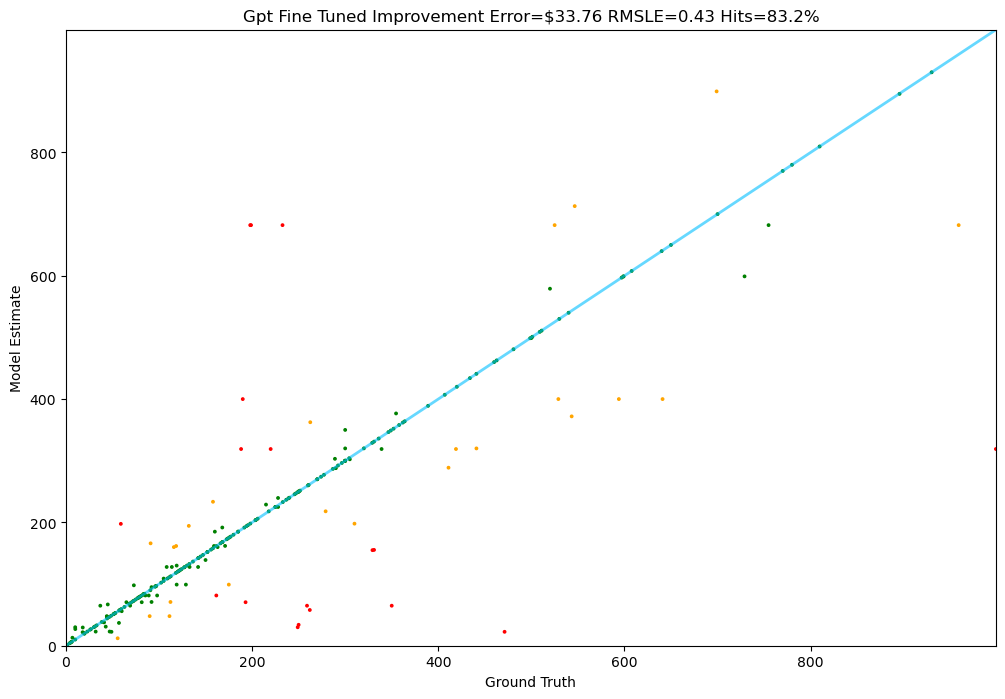

In [93]:
Tester.test(gpt_fine_tuned_improvement, test)

### Finetuned LLM Model Performance Summary

The following table ranks the performance of the models run on the `test.pkl` data, from the most successful (lowest error) to the least successful.

| Model | Average Error (Pricer Error) | RMSLE | Hits (%) |
| :--- | :--- | :--- | :--- |
| **Impovement FineTuned Model** | **$33.76** | **0.43** | **%83.2** |
| FineTuned Model | $122.25 | 0.83 | %41.2 |
